### WestLake PixelRec

In [234]:
!pip install -q lmdb
!pip install -q gdown
!pip install -q colorlog
!pip install -q tensorboardX
!pip install -q colorama
!pip install -q torch_geometric
!pip install -q ultralytics
!pip install -q pillow


In [35]:
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done


In [125]:
import os, pickle
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')

if HF_TOKEN:
    os.environ['HF_TOKEN'] = HF_TOKEN
    login(token=HF_TOKEN, add_to_git_credential=True)
    print("Hugging Face token set and logged in successfully.")
else:
    print("HF_TOKEN not found. Please check your Colab secrets.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Hugging Face token set and logged in successfully.


In [6]:
import sys, torch
print(sys.version)
print(f"PyTorch version: {torch.__version__}")

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.10.0+cpu


In [7]:
import torch

if torch.cuda.is_available():
    print(f"CUDA is available! PyTorch detected {torch.cuda.device_count()} GPU(s).")
    print(f"Current CUDA device name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. PyTorch is running on CPU.")


CUDA is not available. PyTorch is running on CPU.


In [8]:
!cd /content/sample_data/ && git clone https://github.com/westlake-repl/PixelRec.git

Cloning into 'PixelRec'...
remote: Enumerating objects: 558, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 558 (delta 27), reused 3 (delta 1), pack-reused 486 (from 1)
Receiving objects: 100% (558/558), 99.54 MiB | 26.13 MiB/s, done.
Resolving deltas: 100% (218/218), done.


In [9]:
import gdown, os, zipfile

output_dir = '/content/sample_data/PixelRec/'
os.makedirs(output_dir, exist_ok=True)

zip_file_path = os.path.join(output_dir, 'resized_images.zip')
file_id = '1P4kKxL5xgJ_ePj955gIEej78bsnk36M5'

gdown.download(id=file_id, output=zip_file_path, quiet=False)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
 zip_ref.extractall(output_dir)

 print(f"Images extracted directly to {output_dir}")

Downloading...
From (original): https://drive.google.com/uc?id=1P4kKxL5xgJ_ePj955gIEej78bsnk36M5
From (redirected): https://drive.google.com/uc?id=1P4kKxL5xgJ_ePj955gIEej78bsnk36M5&confirm=t&uuid=8e547f2b-0565-4bcf-9df2-592e0644da8e
To: /content/sample_data/PixelRec/resized_images.zip
100%|██████████| 163M/163M [00:03<00:00, 43.0MB/s]


Images extracted directly to /content/sample_data/PixelRec/


In [10]:
# pixelrec interaction csv
import gdown, os, zipfile
output_dir = '/content/sample_data/PixelRec/dataset/pixelrec_interaction'
os.makedirs(output_dir, exist_ok=True)
file_name = os.path.join(output_dir, 'Pixel200K.csv')

#dir_id = '1P4kKxL5xgJ_ePj955gIEej78bsnk36M5'
file_id = '1mDTrnSpWkffG5KHNOV1az14X6r9zrtFy'

gdown.download(id=file_id, output=file_name, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1mDTrnSpWkffG5KHNOV1az14X6r9zrtFy
From (redirected): https://drive.google.com/uc?id=1mDTrnSpWkffG5KHNOV1az14X6r9zrtFy&confirm=t&uuid=bc20ad96-e810-4323-b66f-ea176a490764
To: /content/sample_data/PixelRec/dataset/pixelrec_interaction/Pixel200K.csv
100%|██████████| 109M/109M [00:02<00:00, 42.3MB/s]


'/content/sample_data/PixelRec/dataset/pixelrec_interaction/Pixel200K.csv'

In [11]:
# pixelrec item_information csv
import gdown, os, zipfile
output_dir = '/content/sample_data/PixelRec/dataset/pixelrec_iteminfo'
os.makedirs(output_dir, exist_ok=True)
file_name = os.path.join(output_dir, 'Pixel200K.csv')

#dir_id = '1P4kKxL5xgJ_ePj955gIEej78bsnk36M5'
file_id = '1Zm3iKrVGjV9FbJFYAZYW3LBpuzHBEPBj'

gdown.download(id=file_id, output=file_name, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Zm3iKrVGjV9FbJFYAZYW3LBpuzHBEPBj
To: /content/sample_data/PixelRec/dataset/pixelrec_iteminfo/Pixel200K.csv
100%|██████████| 28.6M/28.6M [00:00<00:00, 54.4MB/s]


'/content/sample_data/PixelRec/dataset/pixelrec_iteminfo/Pixel200K.csv'

In [12]:
import pandas as pd
df_inter = pd.read_csv('/content/sample_data/PixelRec/dataset/pixelrec_interaction/Pixel200K.csv', nrows=1)
display(df_inter)

,item_id,user_id,timestamp
0,i68199,u3328884,1589875802


In [13]:
import pandas as pd
df_iteminfo = pd.read_csv('/content/sample_data/PixelRec/dataset/pixelrec_iteminfo/Pixel200K.csv', nrows=1)
display(df_iteminfo)

,item_id,view_number,comment_number,thumbup_number,share_number,coin_number,favorite_number,barrage_number,title,tag,description
0,i192714,799668.0,739.0,8050.0,220.0,84.0,1049.0,510.0,"My boyfriend gave me a turtle, and it suddenly...",Pet Reptiles,Should I brush it off?


In [87]:
import os
import pandas as pd

csv_path = "/content/sample_data/PixelRec/dataset/pixelrec_iteminfo/Pixel200K.csv"
images_folder = "/content/sample_data/PixelRec/resized_images"

df = pd.read_csv(csv_path)

# Improved matching logic
def find_image_path(item_id):
    item_id_str = str(item_id).strip()
    # Try various combinations of prefixes and extensions
    clean_id = item_id_str[1:] if item_id_str.startswith('i') else item_id_str

    candidates = [
        f"{item_id_str}.jpg", f"{item_id_str}.png",
        f"i{clean_id}.jpg", f"i{clean_id}.png",
        f"{clean_id}.jpg", f"{clean_id}.png"
    ]

    for c in candidates:
        full_path = os.path.join(images_folder, c)
        if os.path.exists(full_path):
            return full_path
    return None

print("Re-mapping image paths with improved matching...")
df["image_path"] = df["item_id"].apply(find_image_path)

# Save the updated mapping
df.to_csv(csv_path, index=False)
print(f"Done. Found {df['image_path'].notna().sum()} images out of {len(df)}.")

Re-mapping image paths with improved matching...
Done. Found 82865 images out of 96282.


In [88]:
import pandas as pd
df_raw = pd.read_csv('/content/sample_data/PixelRec/dataset/pixelrec_iteminfo/Pixel200K.csv', nrows=2)
print(df_raw['image_path'][0])

/content/sample_data/PixelRec/resized_images/i192714.jpg


In [89]:
import os, lmdb, pandas as pd

csv_path = "/content/sample_data/PixelRec/dataset/pixelrec_iteminfo/Pixel200K.csv"
df_full = pd.read_csv(csv_path)
lmdb_file_path = "/content/sample_data/PixelRec/dataset/image.lmdb"

# Overwrite existing LMDB with improved data
env = lmdb.open(lmdb_file_path, map_size=int(1e10), subdir=False)

print(f"Rebuilding LMDB with {len(df_full)} potential items...")

with env.begin(write=True) as txn:
    success_count = 0
    for _, row in df_full.iterrows():
        item_id = str(row["item_id"])
        path = row["image_path"]
        if pd.notna(path) and os.path.exists(str(path)):
            try:
                with open(str(path), "rb") as f:
                    img_bytes = f.read()
                txn.put(item_id.encode("utf-8"), img_bytes)
                success_count += 1
            except:
                pass

print(f"LMDB rebuild complete.")
print(f"Total items stored: {success_count}")
print(f"Missing: {len(df_full) - success_count}")
env.close()

Rebuilding LMDB with 96282 potential items...
LMDB rebuild complete.
Total items stored: 82865
Missing: 13417


In [85]:
import lmdb

lmdb_path = "/content/sample_data/PixelRec/dataset/image.lmdb"
env = lmdb.open(lmdb_path, readonly=True, lock=False, subdir=False)

with env.begin() as txn:
    cursor = txn.cursor()
    for i, (k, v) in enumerate(cursor):
        print(k.decode("utf-8"))
        if i > 5:
            break
env.close()

i10
i1000
i100001
i100015
i100019
i100022
i100024


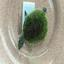

In [86]:
import lmdb, io
from PIL import Image

lmdb_path = "/content/sample_data/PixelRec/dataset/image.lmdb"
item_id = "i192714"

env = lmdb.open(lmdb_path, readonly=True, lock=False, subdir=False)

with env.begin() as txn:
    value = txn.get(item_id.encode("utf-8"))
    if value is None:
        print(f"Item {item_id} not found in LMDB.")
    else:
        img = Image.open(io.BytesIO(value))
        display(img)      # img.show()

env.close()

In [225]:
# Helper to adjust run.py for CPU usage
import os
import re

run_file = '/content/sample_data/PixelRec/code/run.py'

with open(run_file, 'r') as f:
    lines = f.readlines()

new_lines = []
for line in lines:
    indent_match = re.match(r'^(\s*)', line)
    indent = indent_match.group(1) if indent_match else ''

    if 'torch.cuda.set_device(local_rank)' in line:
        line = f"{indent}# torch.cuda.set_device(local_rank)\n"

    elif "device = torch.device('cuda', local_rank)" in line:
        line = f"{indent}device = torch.device('cpu')\n"

    elif "backend='nccl'" in line:
        line = line.replace("backend='nccl'", "backend='gloo'")

    elif "model = torch.nn.SyncBatchNorm.convert_sync_batchnorm(model)" in line:
        line = f"{indent}# model = torch.nn.SyncBatchNorm.convert_sync_batchnorm(model).to(device)\n"
        new_lines.append(line)
        line = f"{indent}model = model.to(device)\n"
        continue

    elif "model = DDP(model, device_ids=[local_rank]" in line:
        line = f"{indent}model = DDP(model, find_unused_parameters=True)\n"

    new_lines.append(line)

with open(run_file, 'w') as f:
    f.writelines(new_lines)

print("Patched run.py: Disabled SyncBatchNorm and forced CPU distribution.")

Patched run.py: Disabled SyncBatchNorm and forced CPU distribution.


In [226]:
import yaml, os

config_path = '/content/sample_data/PixelRec/code/PixelNet/sasrec.yaml'

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = yaml.safe_load(f)
    config_data['num_workers'] = 2

    with open(config_path, 'w') as f:
        yaml.dump(config_data, f, default_flow_style=False)

    print(f"Successfully updated {config_path}: set num_workers to 2.")
else:
    print(f"Config file not found at {config_path}")

Successfully updated /content/sample_data/PixelRec/code/PixelNet/sasrec.yaml: set num_workers to 2.


In [232]:
import yaml, os

config_path = '/content/sample_data/PixelRec/code/overall/ViT.yaml'

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = yaml.safe_load(f)
    config_data['epochs'] = 10

    with open(config_path, 'w') as f:
        yaml.dump(config_data, f, default_flow_style=False)

    print(f"Successfully updated {config_path}: set epochs to 10.")
else:
    print(f"Config file not found at {config_path}")

Successfully updated /content/sample_data/PixelRec/code/overall/ViT.yaml: set epochs to 10.


In [228]:
# Assuring a clean interaction csv
!cd '/content/sample_data/PixelRec/dataset/' && cp 'pixelrec_interaction/Pixel200K.csv' 'Pixel200K.csv'

In [238]:
import yaml
import os

lmdb_path = '/content/sample_data/PixelRec/dataset/image.lmdb'
config_files = [
    '/content/sample_data/PixelRec/code/PixelNet/sasrec.yaml',
    '/content/sample_data/PixelRec/code/overall/ViT.yaml'
]

for path in config_files:
    if os.path.exists(path):
        with open(path, 'r') as f:
            config = yaml.safe_load(f) or {}

        config['image_path'] = lmdb_path

        with open(path, 'w') as f:
            yaml.dump(config, f, default_flow_style=False)
        print(f"Updated {path} with image_path.")
    else:
        print(f"Config not found: {path}")

Updated /content/sample_data/PixelRec/code/PixelNet/sasrec.yaml with image_path.
Updated /content/sample_data/PixelRec/code/overall/ViT.yaml with image_path.


In [239]:
!cd /content/sample_data/PixelRec/code && python main.py --device 0 --config_file PixelNet/sasrec.yaml overall/ViT.yaml

[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
11 May 04:30    INFO  [Training]: train_batch_size = [16]
11 May 04:30    INFO  [Evaluation]: eval_batch_size = [1024]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
11 May 04:30    INFO  HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
11 May 04:30    INFO  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268

In [ ]:
!cd /content/sample_data/PixelRec/code && python main.py --config_file PixelNet/yolo.yaml overall/ID.yaml